In [20]:
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import(mean_absolute_error, mean_squared_error)

Load Clean Dataset

In [22]:
df = pd.read_csv("../data/processed/cleaned_metal_prices.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.set_index("Date", inplace=True)

df.head()

,Year,Month,Price_alum,Price_gold,Price_nickel,Price_silver,Price_uran,Inflation_rate,Price_alum_infl,Price_gold_infl,Price_nickel_infl,Price_silver_infl,Price_uran_infl
Date,,,,,,,,,,,,,
1992-02-01,1992,Feb,1266.83,353.91,7861.9,4.15,7.90,89.59,2401.782997,670.977969,14905.37621,7.867985,14.977610
1992-03-01,1992,Mar,1280.47,344.34,7417.7,4.11,7.75,89.59,2427.643073,652.834206,14063.21743,7.792149,14.693225
1992-04-01,1992,Apr,1317.05,338.62,7420.6,4.05,7.75,89.59,2496.995095,641.989658,14068.71554,7.678395,14.693225
1992-05-01,1992,May,1306.79,337.24,7326.8,4.07,7.55,89.59,2477.543161,639.373316,13890.88012,7.716313,14.314045
1992-06-01,1992,Jun,1275.55,340.81,7192.8,4.06,7.75,89.59,2418.315245,646.141679,13636.82952,7.697354,14.693225


In [23]:
gold = df["Price_gold"]

Visualize time series

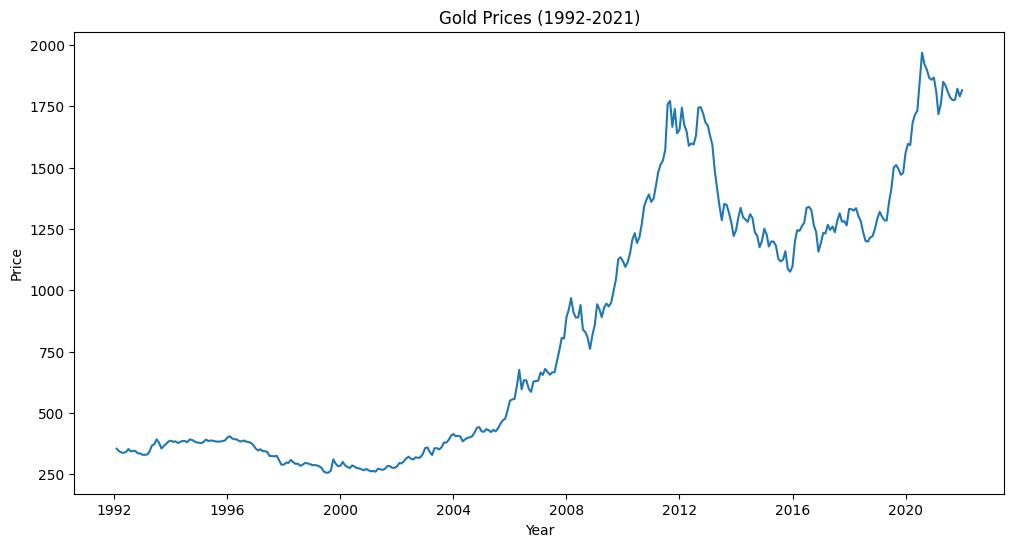

In [24]:
plt.figure(figsize=(12,6))
plt.plot(gold)
plt.title("Gold Prices (1992-2021)")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

Train-Test split

In [25]:
train_size = int(len(gold) * 0.8)

train = gold[:train_size]

test = gold[train_size:]

ARIMA MODEL

In [26]:
model = ARIMA(train, order=(5,1,0)) # p,d,q values can be tuned for better performance
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Price_gold   No. Observations:                  288
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -1393.243
Date:                Thu, 04 Jun 2026   AIC                           2798.485
Time:                        13:26:42   BIC                           2820.442
Sample:                    02-01-1992   HQIC                          2807.285
                         - 01-01-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1733      0.045      3.881      0.000       0.086       0.261
ar.L2         -0.0677      0.034     -2.017      0.044      -0.133      -0.002
ar.L3          0.0924      0.042      2.183      0.0

C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Forecast -
predicting for test period

In [27]:
forecast = model_fit.forecast(steps=len(test))


Evaluate

MAE

In [28]:
mae = mean_absolute_error(test, forecast)
print("MAE:", mae)

MAE: 374.56153808686224


RMSE

In [29]:
rmse = np.sqrt(mean_squared_error(test,forecast))
print("RMSE:", rmse)

RMSE: 450.2389833975868


Visualization

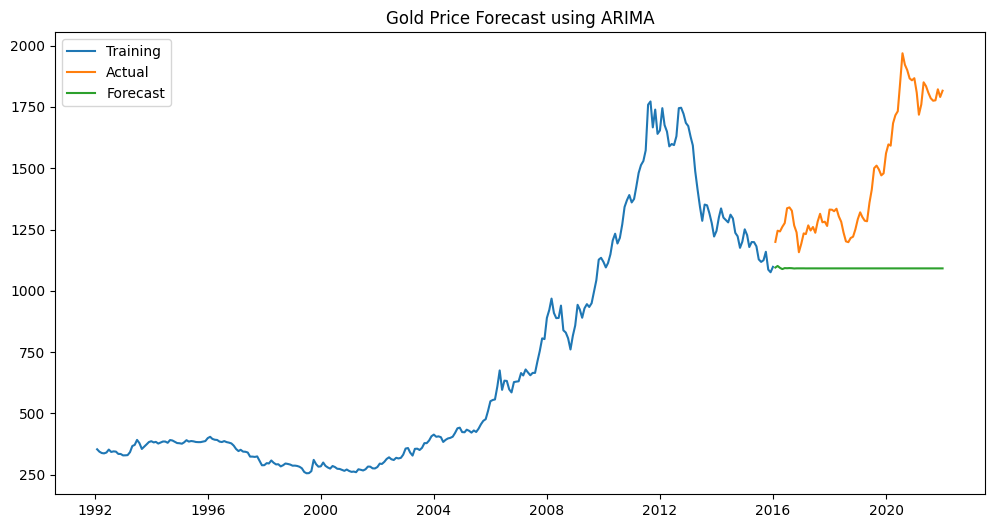

In [30]:
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train,
    label="Training"
)

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    test.index,
    forecast,
    label="Forecast"
)

plt.title(
    "Gold Price Forecast using ARIMA"
)

plt.legend()

plt.show()

In [31]:
final_model = ARIMA(gold, order=(5,1,0))

final_fit = final_model.fit()

C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Forecast future dates

next 12 months

In [32]:
future_forecast = final_fit.forecast(steps=12)

print(future_forecast)

2022-02-01    1825.057454
2022-03-01    1822.081649
2022-04-01    1829.430304
2022-05-01    1826.553045
2022-06-01    1828.417814
2022-07-01    1830.803311
2022-08-01    1830.366169
2022-09-01    1831.305920
2022-10-01    1831.214446
2022-11-01    1831.273596
2022-12-01    1831.689902
2023-01-01    1831.679516
Freq: MS, Name: predicted_mean, dtype: float64


Create future dates

In [33]:
future_dates = pd.date_range(
    start=gold.index[-1],
    periods=13,
    freq="MS"
)[1:]

Put the forecaste data in dataframe

In [ ]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Gold_Price": future_forecast
})

forecast_df

,Date,Forecasted_Gold_Price
2022-02-01,2022-02-01,1825.057454
2022-03-01,2022-03-01,1822.081649
2022-04-01,2022-04-01,1829.430304
2022-05-01,2022-05-01,1826.553045
2022-06-01,2022-06-01,1828.417814
2022-07-01,2022-07-01,1830.803311
2022-08-01,2022-08-01,1830.366169
2022-09-01,2022-09-01,1831.305920
2022-10-01,2022-10-01,1831.214446
2022-11-01,2022-11-01,1831.273596


Plot the future forecast

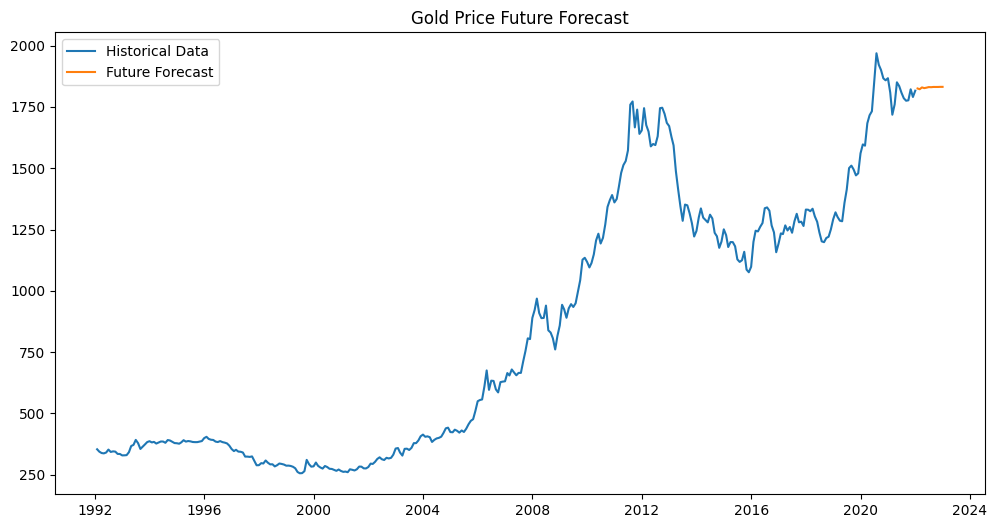

In [35]:
plt.figure(figsize=(12,6))

plt.plot(
    gold,
    label="Historical Data"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecasted_Gold_Price"],
    label="Future Forecast"
)

plt.title(
    "Gold Price Future Forecast"
)

plt.legend()

plt.show()

Arima forecating for all the metals

In [36]:
metals = [
    "Price_gold",
    "Price_silver",
    "Price_alum",
    "Price_nickel",
    "Price_uran"
]

In [37]:
from statsmodels.tsa.arima.model import ARIMA

forecast_results = {}

for metal in metals:

    print(f"Forecasting {metal}")

    series = df[metal]

    model = ARIMA(
        series,
        order=(5,1,0)
    )

    model_fit = model.fit()

    future_forecast = model_fit.forecast(
        steps=12
    )

    forecast_results[metal] = future_forecast

    print(future_forecast)

Forecasting Price_gold
2022-02-01    1825.057454
2022-03-01    1822.081649
2022-04-01    1829.430304
2022-05-01    1826.553045
2022-06-01    1828.417814
2022-07-01    1830.803311
2022-08-01    1830.366169
2022-09-01    1831.305920
2022-10-01    1831.214446
2022-11-01    1831.273596
2022-12-01    1831.689902
2023-01-01    1831.679516
Freq: MS, Name: predicted_mean, dtype: float64
Forecasting Price_silver


C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-package

2022-02-01    23.526858
2022-03-01    23.654558
2022-04-01    23.472773
2022-05-01    23.426969
2022-06-01    23.488400
2022-07-01    23.535497
2022-08-01    23.524593
2022-09-01    23.505233
2022-10-01    23.505885
2022-11-01    23.515076
2022-12-01    23.517719
2023-01-01    23.514915
Freq: MS, Name: predicted_mean, dtype: float64
Forecasting Price_alum
2022-02-01    3048.878369
2022-03-01    3018.365125
2022-04-01    3059.541350
2022-05-01    3106.324041
2022-06-01    3104.032174
2022-07-01    3100.811402
2022-08-01    3110.558087
2022-09-01    3116.108076
2022-10-01    3114.466632
2022-11-01    3114.604010
2022-12-01    3116.446820
2023-01-01    3116.902138
Freq: MS, Name: predicted_mean, dtype: float64
Forecasting Price_nickel
2022-02-01    23179.691098
2022-03-01    23553.808430
2022-04-01    23343.351181
2022-05-01    23218.195041
2022-06-01    23306.587698
2022-07-01    23452.536377
2022-08-01    23553.496593
2022-09-01    23559.154306
2022-10-01    23531.270969
2022-11-01    2

C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\LIANNAKA DADI\AppData\Roaming\Python\Python313\site-package

2022-02-01    32.668571
2022-03-01    33.027152
2022-04-01    32.322817
2022-05-01    31.778584
2022-06-01    31.577759
2022-07-01    31.738168
2022-08-01    31.930003
2022-09-01    31.962738
2022-10-01    31.892034
2022-11-01    31.818083
2022-12-01    31.800683
2023-01-01    31.824695
Freq: MS, Name: predicted_mean, dtype: float64


In [38]:
import os

os.makedirs(
    "../predictions/arima",
    exist_ok=True
)

In [39]:
pred_df = pd.DataFrame({
    "Actual": test.values,
    "Forecast": forecast.values
})

pred_df.to_csv(
    f"../predictions/arima/{metal}_arima_predictions.csv",
    index=False
)

In [40]:
future_dates = pd.date_range(
    start=df.index[-1],
    periods=13,
    freq="MS"
)[1:]

In [41]:
forecast_df = pd.DataFrame({
    "Date": future_dates
})

for metal in metals:
    forecast_df[metal] = forecast_results[metal].values

forecast_df

,Date,Price_gold,Price_silver,Price_alum,Price_nickel,Price_uran
0,2022-02-01,1825.057454,23.526858,3048.878369,23179.691098,32.668571
1,2022-03-01,1822.081649,23.654558,3018.365125,23553.808430,33.027152
2,2022-04-01,1829.430304,23.472773,3059.541350,23343.351181,32.322817
3,2022-05-01,1826.553045,23.426969,3106.324041,23218.195041,31.778584
4,2022-06-01,1828.417814,23.488400,3104.032174,23306.587698,31.577759
5,2022-07-01,1830.803311,23.535497,3100.811402,23452.536377,31.738168
6,2022-08-01,1830.366169,23.524593,3110.558087,23553.496593,31.930003
7,2022-09-01,1831.305920,23.505233,3116.108076,23559.154306,31.962738
8,2022-10-01,1831.214446,23.505885,3114.466632,23531.270969,31.892034
9,2022-11-01,1831.273596,23.515076,3114.604010,23514.787472,31.818083


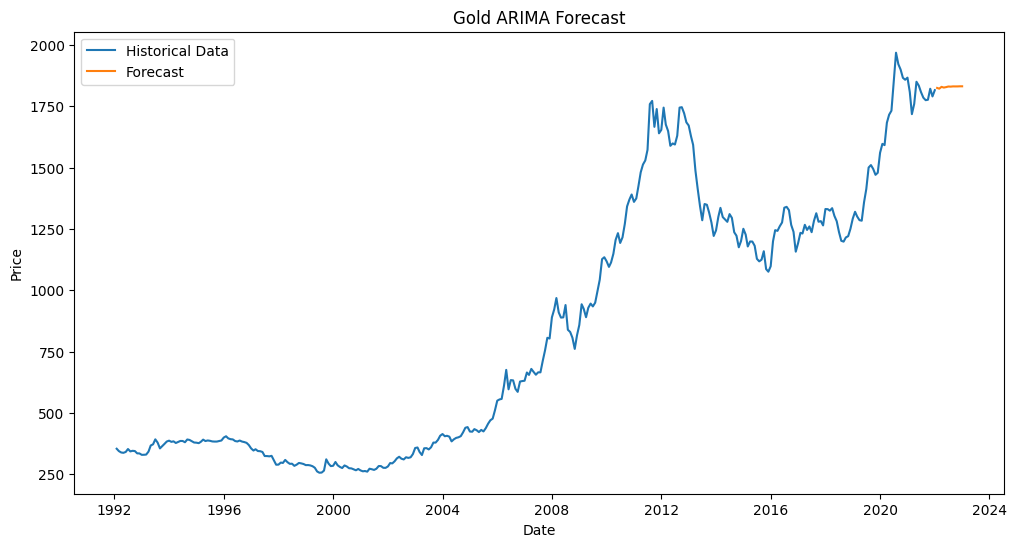

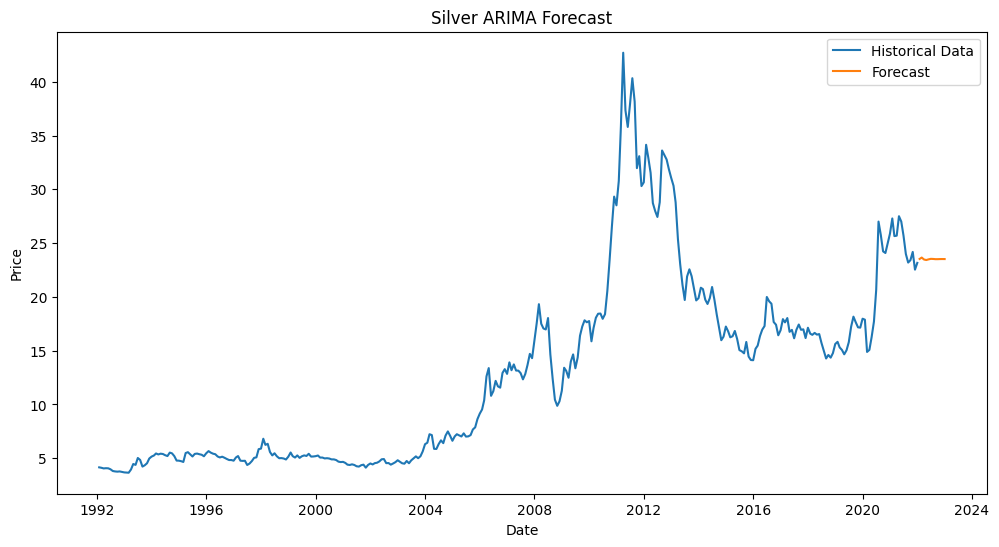

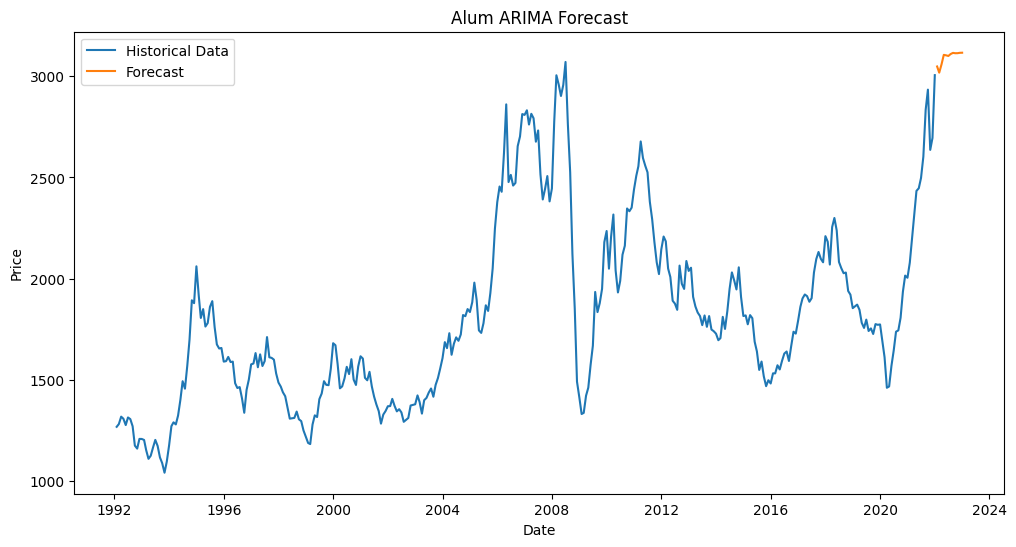

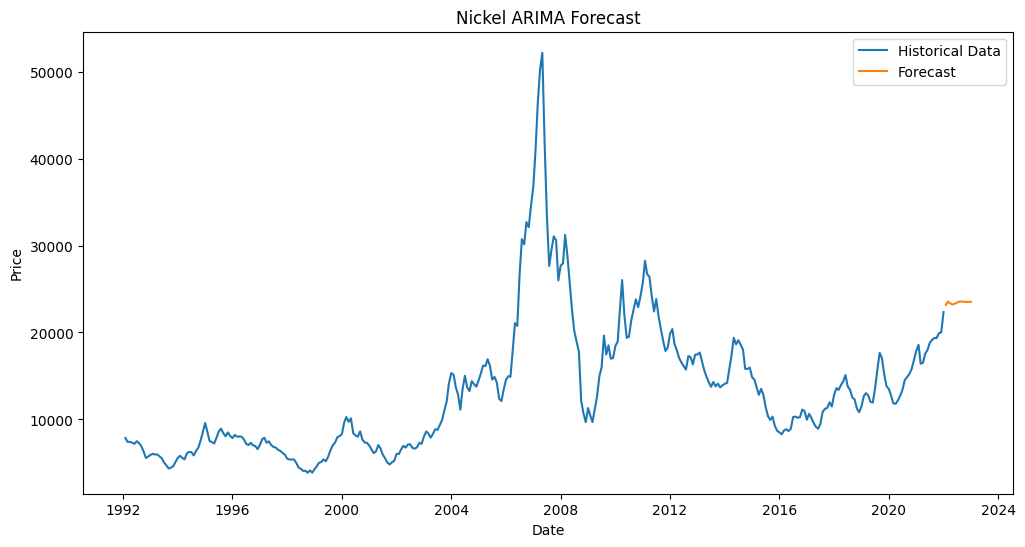

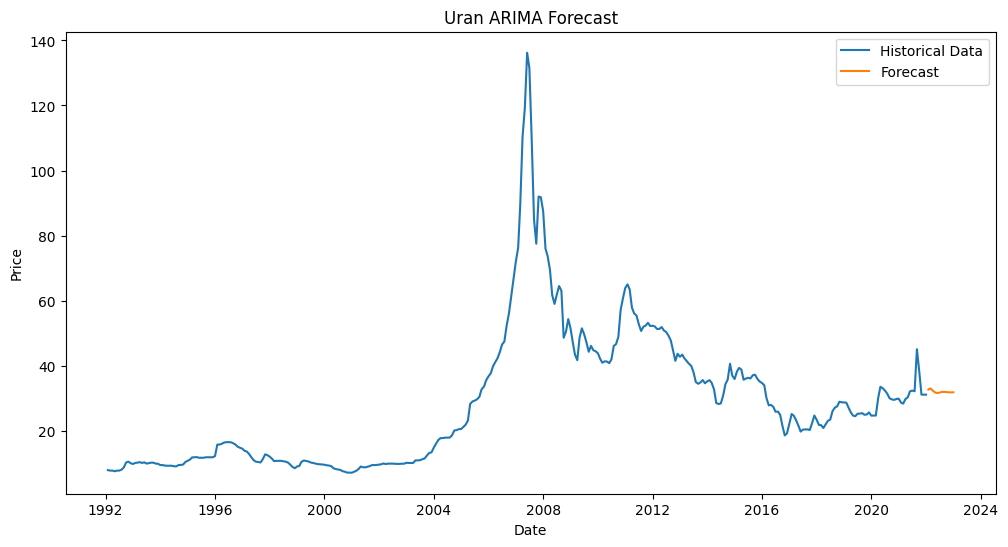

In [42]:
for metal in metals:

    plt.figure(figsize=(12,6))

    plt.plot(
        df[metal],
        label="Historical Data"
    )

    plt.plot(
        future_dates,
        forecast_results[metal],
        label="Forecast"
    )

    clean_name = (
        metal
        .replace("Price_", "")
        .capitalize()
    )

    plt.title(
        f"{clean_name} ARIMA Forecast"
    )

    plt.xlabel("Date")
    plt.ylabel("Price")

    plt.legend()

    plt.show()

In [43]:
forecast_df.to_csv(
    "../data/processed/ARIMA_Forecasts.csv",
    index=False
)